In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# 한글 폰트 설정 (korean_font.py 사용)
import sys
sys.path.append('..') # 상위 디렉토리에 있는 korean_font.py를 불러옵니다.
from korean_font import set_korean_font
set_korean_font()

# 데이터 로드
train = pd.read_csv('data/train.csv')
test = pd.read_csv('data/test.csv')
submission = pd.read_csv('data/sample_submission.csv')

한글 폰트 설정: Malgun Gothic (c:/Windows/Fonts/malgun.ttf)


,일자,요일,본사정원수,본사휴가자수,본사출장자수,본사시간외근무명령서승인건수,현본사소속재택근무자수,조식메뉴,중식메뉴,석식메뉴,중식계,석식계
0,2016-02-01,월,2601,50,150,238,0.0,모닝롤/찐빵 우유/두유/주스 계란후라이 호두죽/쌀밥 (쌀:국내산) 된장찌개 쥐...,"쌀밥/잡곡밥 (쌀,현미흑미:국내산) 오징어찌개 쇠불고기 (쇠고기:호주산) 계란찜 ...","쌀밥/잡곡밥 (쌀,현미흑미:국내산) 육개장 자반고등어구이 두부조림 건파래무침 ...",1039.0,331.0
1,2016-02-02,화,2601,50,173,319,0.0,모닝롤/단호박샌드 우유/두유/주스 계란후라이 팥죽/쌀밥 (쌀:국내산) 호박젓국찌...,"쌀밥/잡곡밥 (쌀,현미흑미:국내산) 김치찌개 가자미튀김 모둠소세지구이 마늘쫑무...","콩나물밥*양념장 (쌀,현미흑미:국내산) 어묵국 유산슬 (쇠고기:호주산) 아삭고추무...",867.0,560.0
2,2016-02-03,수,2601,56,180,111,0.0,모닝롤/베이글 우유/두유/주스 계란후라이 표고버섯죽/쌀밥 (쌀:국내산) 콩나물국...,"카레덮밥 (쌀,현미흑미:국내산) 팽이장국 치킨핑거 (닭고기:국내산) 쫄면야채무침 ...","쌀밥/잡곡밥 (쌀,현미흑미:국내산) 청국장찌개 황태양념구이 (황태:러시아산) 고기...",1017.0,573.0
3,2016-02-04,목,2601,104,220,355,0.0,"모닝롤/토마토샌드 우유/두유/주스 계란후라이 닭죽/쌀밥 (쌀,닭:국내산) 근대국...","쌀밥/잡곡밥 (쌀,현미흑미:국내산) 쇠고기무국 주꾸미볶음 부추전 시금치나물 ...","미니김밥*겨자장 (쌀,현미흑미:국내산) 우동 멕시칸샐러드 군고구마 무피클 포...",978.0,525.0
4,2016-02-05,금,2601,278,181,34,0.0,모닝롤/와플 우유/두유/주스 계란후라이 쇠고기죽/쌀밥 (쌀:국내산) 재첩국 방...,"쌀밥/잡곡밥 (쌀,현미흑미:국내산) 떡국 돈육씨앗강정 (돼지고기:국내산) 우엉잡채...","쌀밥/잡곡밥 (쌀,현미흑미:국내산) 차돌박이찌개 (쇠고기:호주산) 닭갈비 (닭고기:...",925.0,330.0


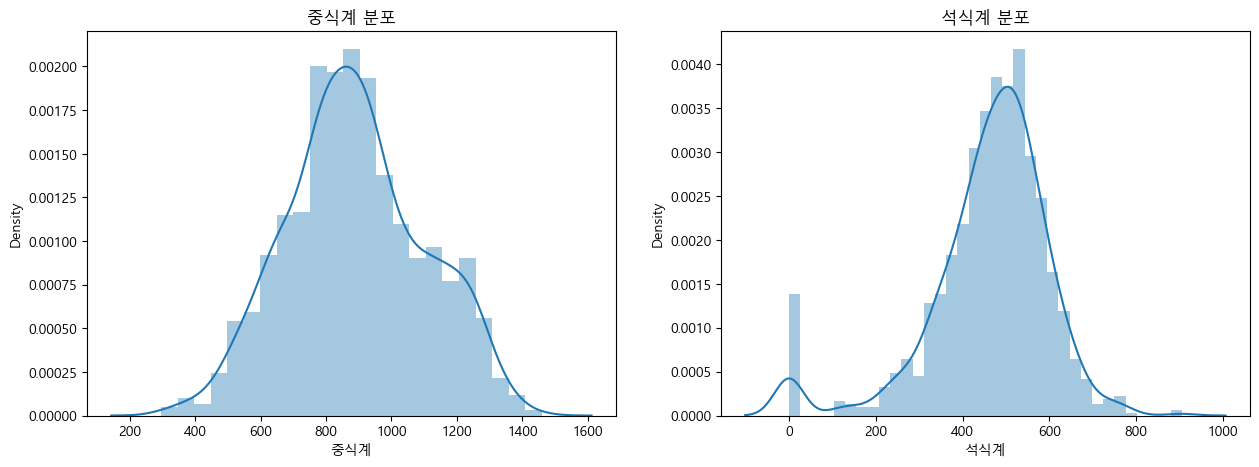

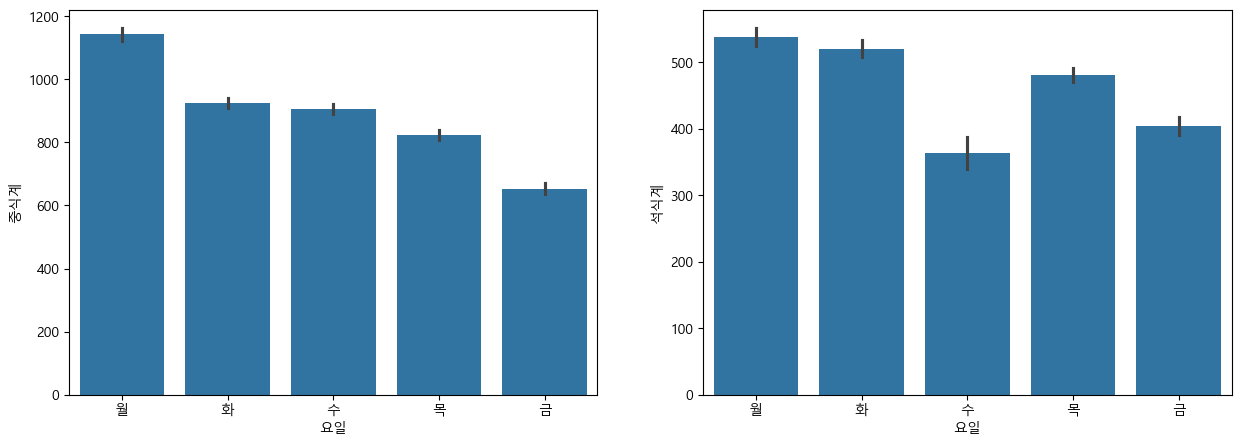

In [2]:
# 상위 데이터 확인
display(train.head())

# 타겟 변수(중식계, 석식계)의 분포 확인
fig, ax = plt.subplots(1, 2, figsize=(15, 5))
sns.distplot(train['중식계'], ax=ax[0]).set_title('중식계 분포')
sns.distplot(train['석식계'], ax=ax[1]).set_title('석식계 분포')
plt.show()

# 요일별 식사 인원 평균 시각화
fig, ax = plt.subplots(1, 2, figsize=(15, 5))
sns.barplot(x='요일', y='중식계', data=train, ax=ax[0], order=['월', '화', '수', '목', '금'])
sns.barplot(x='요일', y='석식계', data=train, ax=ax[1], order=['월', '화', '수', '목', '금'])
plt.show()

In [3]:
def preprocess(df):
    # 1. 날짜 데이터 분리
    df['일자'] = pd.to_datetime(df['일자'])
    df['년'] = df['일자'].dt.year
    df['월'] = df['일자'].dt.month
    df['일'] = df['일자'].dt.day
    df['주차'] = df['일자'].dt.isocalendar().week.astype(int)
    
    # 2. 요일 숫자 매핑
    weekday_map = {'월': 0, '화': 1, '수': 2, '목': 3, '금': 4}
    df['요일'] = df['요일'].map(weekday_map)
    
    # 3. 핵심 변수: 실제 근무자 수 계산
    # (본사정원수 - 휴가자 - 출장자 - 재택근무자)
    df['실제근무자'] = df['본사정원수'] - df['본사휴가자수'] - df['본사출장자수'] - df['현본사소속재택근무자수']
    
    # 4. 시간외근무(야근)와 석식의 상관관계 처리를 위한 파생변수
    # (석식계 예측에 매우 중요)
    
    return df

train_df = preprocess(train)
test_df = preprocess(test)

# 학습에 사용할 특성(Feature) 선택
features = ['요일', '년', '월', '일', '주차', '본사시간외근무명령서승인건수', '실제근무자', '본사출장자수']
X_train = train_df[features]
y_lunch = train_df['중식계']
y_dinner = train_df['석식계']
X_test = test_df[features]

In [4]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import cross_val_score

# 모델 정의
# 'mae'를 'absolute_error'로 변경
model_lunch = RandomForestRegressor(n_estimators=1000, criterion='absolute_error', random_state=42)
model_dinner = RandomForestRegressor(n_estimators=1000, criterion='absolute_error', random_state=42)

# 중식계 학습
model_lunch.fit(X_train, y_lunch)
print("중식계 모델 학습 완료")

# 석식계 학습
model_dinner.fit(X_train, y_dinner)
print("석식계 모델 학습 완료")

중식계 모델 학습 완료
석식계 모델 학습 완료


In [5]:
from sklearn.metrics import mean_absolute_error

# 검증을 위해 데이터를 나눠서 성능 확인 (Hold-out)
from sklearn.model_selection import train_test_split
x_t, x_v, y_t, y_v = train_test_split(X_train, y_lunch, test_size=0.2, random_state=42)

val_model = RandomForestRegressor(n_estimators=100, random_state=42)
val_model.fit(x_t, y_t)
preds = val_model.predict(x_v)

print(f"중식계 검증 MAE: {mean_absolute_error(y_v, preds):.4f}")

# 최종 테스트 데이터 예측
final_pred_lunch = model_lunch.predict(X_test)
final_pred_dinner = model_dinner.predict(X_test)

# 결과 저장
submission['중식계'] = final_pred_lunch
submission['석식계'] = final_pred_dinner
submission.to_csv('submission_rf.csv', index=False)

중식계 검증 MAE: 78.1538
